In [25]:

import pandas as pd

# 1. Load the dataset (using 'latin-1' encoding to avoid errors with special characters)
file_path = 'Global YouTube Statistics.csv'  # Ensure the name matches your file
df = pd.read_csv(file_path, encoding='latin-1')

# 2. Quick inspection: What do we have here?
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 3. View the first rows to understand the structure
print("Data preview:")
display(df.head())

# 4. Review data types and missing values (Critical for cleaning)
print("\nTechnical structure of the dataset:")
df.info()

The dataset contains 995 rows and 28 columns.

Data preview:


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,"228,000,000,000",Music,T-Series,20082,India,IN,Music,...,"2,000,000","2,006",Mar,13,28,"1,366,417,754",5,"471,031,528",21,79
1,2,YouTube Movies,170000000,0,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,"2,006",Mar,5,88,"328,239,523",15,"270,663,028",37,-96
2,3,MrBeast,166000000,"28,368,841,870",Entertainment,MrBeast,741,United States,US,Entertainment,...,"8,000,000","2,012",Feb,20,88,"328,239,523",15,"270,663,028",37,-96
3,4,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000",Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,"1,000,000","2,006",Sep,1,88,"328,239,523",15,"270,663,028",37,-96
4,5,SET India,159000000,"148,000,000,000",Shows,SET India,116536,India,IN,Entertainment,...,"1,000,000","2,006",Sep,20,28,"1,366,417,754",5,"471,031,528",21,79



Technical structure of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_r

In [26]:

# 1. Feature selection: Keeping relevant columns for analysis
cols_to_keep = ['Youtuber', 'subscribers', 'video views', 'category', 'uploads',
                'Country', 'highest_yearly_earnings', 'created_year']

df_clean = df[cols_to_keep].copy()

# 2. Standardize column names to Title Case
df_clean.columns = [col.title() for col in df_clean.columns]

# 3. Clean column names: Replace underscores with spaces
df_clean.columns = df_clean.columns.str.replace('_', ' ')

# 4. Handle missing values in categorical variables
df_clean['Country'] = df_clean['Country'].fillna('Unknown')
df_clean['Category'] = df_clean['Category'].fillna('Unknown')

# 5. Handle missing values in numerical variables
df_clean = df_clean.dropna(subset=['Created Year'])

# 6. Data Type Conversion: Convert 'Created Year' to integer (removes the ".0")
df_clean['Created Year'] = df_clean['Created Year'].astype(int)

# 7. Formatting: Use commas for thousands and zero decimal places for display
pd.options.display.float_format = '{:,.0f}'.format

# 8. Verification
print("Available columns now:")
print(df_clean.columns.tolist())
display(df_clean.head())

Available columns now:
['Youtuber', 'Subscribers', 'Video Views', 'Category', 'Uploads', 'Country', 'Highest Yearly Earnings', 'Created Year']


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year
0,T-Series,245000000,"228,000,000,000",Music,20082,India,"108,400,000",2006
1,YouTube Movies,170000000,0,Film & Animation,1,United States,1,2006
2,MrBeast,166000000,"28,368,841,870",Entertainment,741,United States,"64,700,000",2012
3,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000",Education,966,United States,"94,800,000",2006
4,SET India,159000000,"148,000,000,000",Shows,116536,India,"87,500,000",2006


The folder 'visuals' already exists.


/tmp/ipykernel_13799/646058255.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x='Highest Yearly Earnings', y='Category', data=category_earnings, palette='magma', edgecolor='0.3')


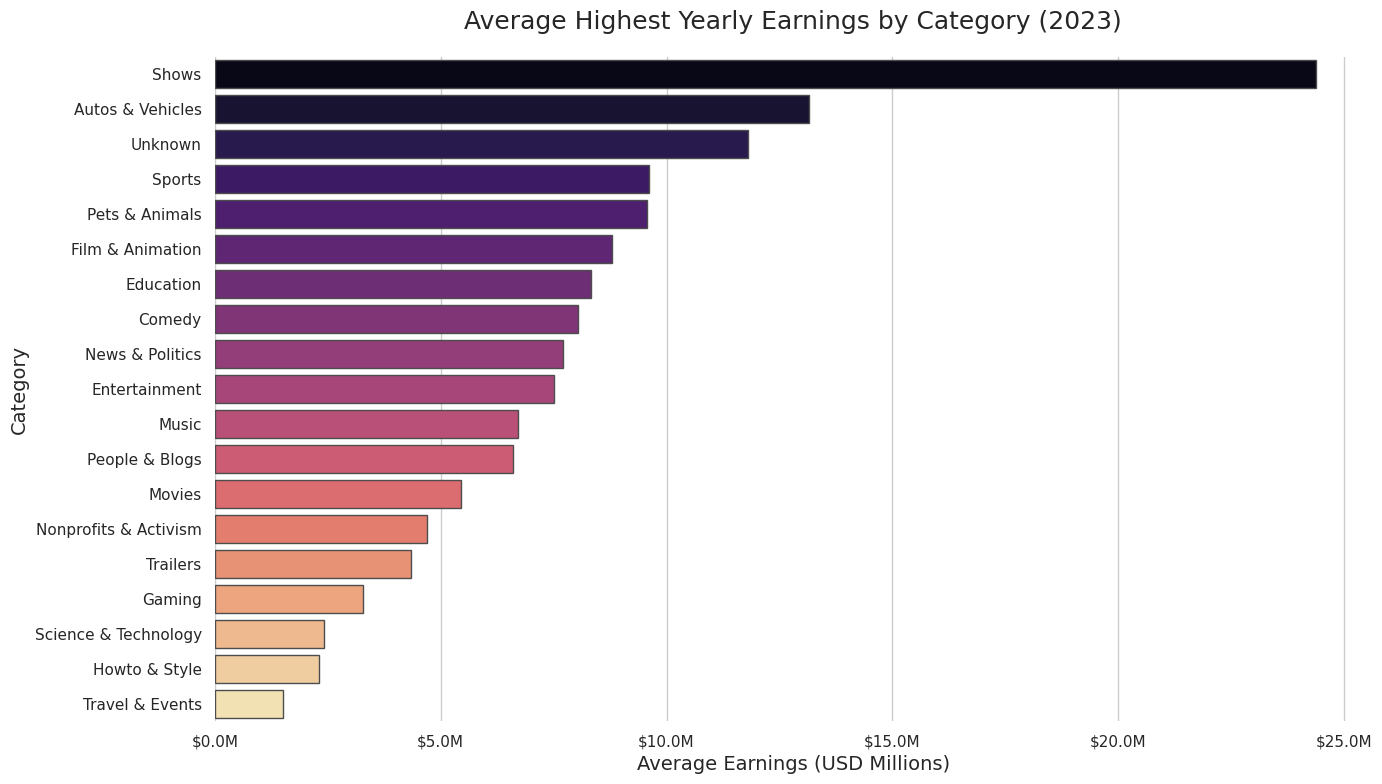

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

# 1. Create the 'visuals' folder if it does not exist
visuals_folder = 'visuals'
if not os.path.exists(visuals_folder):
    os.makedirs(visuals_folder)
    print(f"Folder '{visuals_folder}' created successfully.")
else:
    print(f"The folder '{visuals_folder}' already exists.")

# 2. Plot configuration
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 3. Data Processing: Group by Category and calculate the mean of Highest Yearly Earnings
category_earnings = df_clean.groupby('Category')['Highest Yearly Earnings'].mean().sort_values(ascending=False).reset_index()

# 4. Create the Bar Plot
chart = sns.barplot(x='Highest Yearly Earnings', y='Category', data=category_earnings, palette='magma', edgecolor='0.3')

# 5. Format X-axis for readability (USD Millions)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:,.1f}M')
chart.xaxis.set_major_formatter(formatter)

# 6. Labels and Titles in English
plt.title('Average Highest Yearly Earnings by Category (2023)', fontsize=18, pad=20)
plt.xlabel('Average Earnings (USD Millions)', fontsize=14)
plt.ylabel('Category', fontsize=14)

# 7. Final adjustments and saving
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('visuals/earnings_by_category.png', dpi=300, bbox_inches="tight")
plt.show()

In [28]:
# 1. Count how many "Unknown" values exist compared to the rest
unknown_count = (df_clean['Category'] == 'Unknown').sum()
total_rows = len(df_clean)

print(f"Number of 'Unknown' entries in the 'Category' column: {unknown_count}")
print(f"Total rows in the dataset: {total_rows}")

# 2. Filter the DataFrame to retrieve only the rows where Category is 'Unknown'
# We use .head(10) to inspect the first 10 occurrences
unknown_channels = df_clean[df_clean['Category'] == 'Unknown'].head(10)

# 2. Display the result
print("Audit: Channels with 'Unknown' Category:")
display(unknown_channels)

# 3. Calculate the percentage of the total they represent
total_unknown = (df_clean['Category'] == 'Unknown').sum()
percentage = (total_unknown / len(df_clean)) * 100

print(f"\nPortfolio Insight: There are {total_unknown} channels without a category ({percentage:.2f}% of the dataset).")

Number of 'Unknown' entries in the 'Category' column: 46
Total rows in the dataset: 990
Audit: Channels with 'Unknown' Category:


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year
5,Music,119000000,0,Unknown,0,Unknown,0,2013
12,Gaming,93600000,0,Unknown,0,Unknown,0,2013
18,Sports,75000000,0,Unknown,3,United States,1,2006
91,Vlad vï¿½ï¿½ï,37900000,"23,510,152,352",Unknown,515,United States,"11,700,000",2018
102,News,36300000,0,Unknown,0,Unknown,0,2013
132,BETER Bï¿½ï¿½,32700000,"19,180,039,918",Unknown,2738,Turkey,"70,200,000",2012
155,Diana and Roma ESP,30700000,"12,355,992,466",Unknown,578,United States,"4,900,000",2016
161,ýýýýýýýýýýýýýýý ýýýýýý ýýýýýýýýýýýýýýýýýý,30400000,"17,999,961,915",Unknown,532,United States,"5,900,000",2018
173,Popular on YouTube,29300000,0,Unknown,3,Unknown,0,2017
214,D Billions,26200000,"31,977,463,002",Unknown,775,United States,"23,400,000",2019



Portfolio Insight: There are 46 channels without a category (4.65% of the dataset).


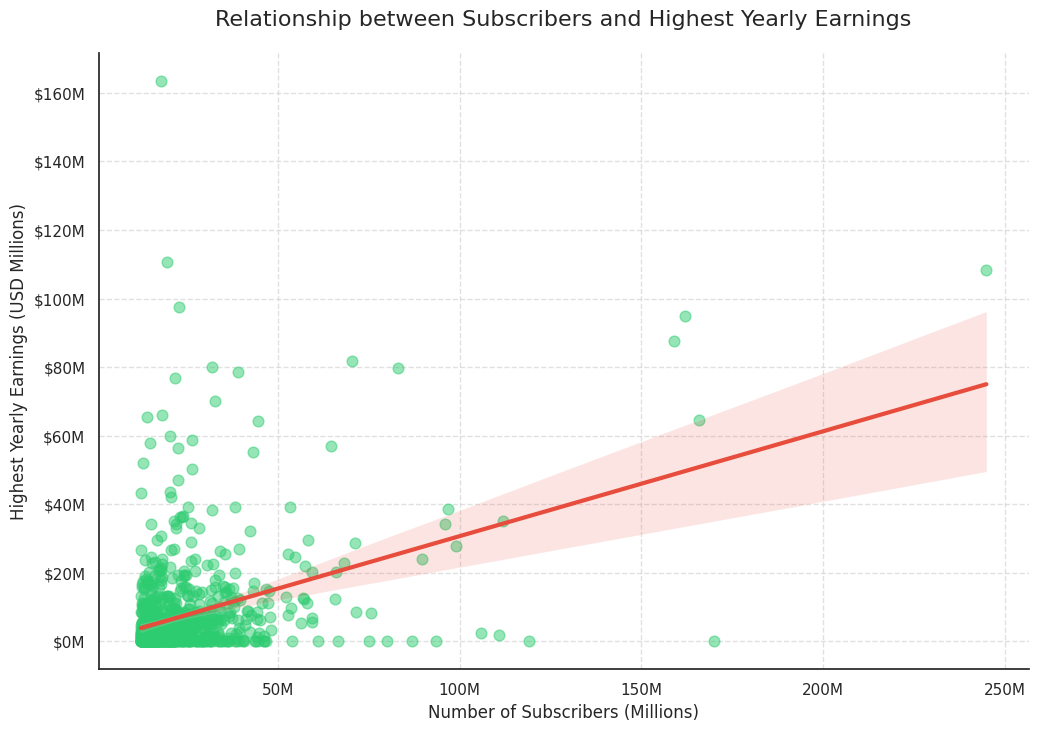

The Pearson Correlation Coefficient is: 0.39


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Figure configuration
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# 2. Scatter Plot creation
# We use 'regplot' to automatically draw the trend line
scatter = sns.regplot(data=df_clean,
    x='Subscribers',
    y='Highest Yearly Earnings',
    scatter_kws={'alpha':0.5, 's':60, 'color':'#2ecc71'}, # Semi-transparent green points
    line_kws={'color':'#e74c3c', 'lw':3} # Red trend line
)

# 3. Format axes for readability ($M for money and M for subscribers)
formatter_money = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:,.0f}M')
formatter_subs = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.0f}M')

plt.gca().yaxis.set_major_formatter(formatter_money)
plt.gca().xaxis.set_major_formatter(formatter_subs)

# 4. Titles and labels
plt.title('Relationship between Subscribers and Highest Yearly Earnings', fontsize=16, pad=20)
plt.xlabel('Number of Subscribers (Millions)', fontsize=12)
plt.ylabel('Highest Yearly Earnings (USD Millions)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.savefig('visuals/subscribers_vs_earnings_scatter.png', dpi=300, bbox_inches="tight")
plt.show()

# 5. Mathematical calculation of correlation (The expert touch)
correlation = df_clean['Subscribers'].corr(df_clean['Highest Yearly Earnings'])
print(f"The Pearson Correlation Coefficient is: {correlation:.2f}")

In [30]:
# 1. Calculate average views per uploaded video
# We filter out channels with 0 uploads to avoid division by zero errors
df_clean_filtered = df_clean[df_clean['Uploads'] > 0].copy()
df_clean_filtered['Views Per Video'] = df_clean_filtered['Video Views'] / df_clean_filtered['Uploads']

# 2. Identify the "Snipers" (high efficiency: creators with most views per individual video)
top_efficient = df_clean_filtered.sort_values(by='Views Per Video', ascending=False).head(10)

# 3. Display the results
print("Top 10 Most Efficient Content Creators (Views per Video):")
display(top_efficient)

Top 10 Most Efficient Content Creators (Views per Video):


,Youtuber,Subscribers,Video Views,Category,Uploads,Country,Highest Yearly Earnings,Created Year,Views Per Video
51,Bad Bunny,46100000,"30,686,342,319",Music,1,Unknown,0,2005,"30,686,342,319"
16,5-Minute Crafts,80100000,"26,236,790,209",Howto & Style,1,United Kingdom,0,2020,"26,236,790,209"
14,Goldmines,86900000,"24,118,230,580",Film & Animation,1,Unknown,1,2006,"24,118,230,580"
50,A4,46300000,"22,936,630,813",Gaming,1,Cuba,5,2006,"22,936,630,813"
77,LUCCAS NETO - LUCCAS TOON,39400000,"22,302,547,082",People & Blogs,1,Unknown,0,2021,"22,302,547,082"
48,Badabun,46800000,"19,398,045,702",Entertainment,1,Unknown,21,2007,"19,398,045,702"
220,Marï¿½ï¿½ï¿½ï¿½ï¿½,26000000,"18,597,534,412",Music,1,Unknown,0,2008,"18,597,534,412"
570,Alfredo Larin,16400000,"14,431,830,557",Entertainment,1,Unknown,0,2015,"14,431,830,557"
986,ANNA KOVA,12400000,"13,959,586,308",People & Blogs,1,Unknown,0,2006,"13,959,586,308"
569,RCTI - LAYAR DRAMA INDONESIA,16400000,"13,478,392,540",Entertainment,1,Unknown,0,2020,"13,478,392,540"


/tmp/ipykernel_13799/558299190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


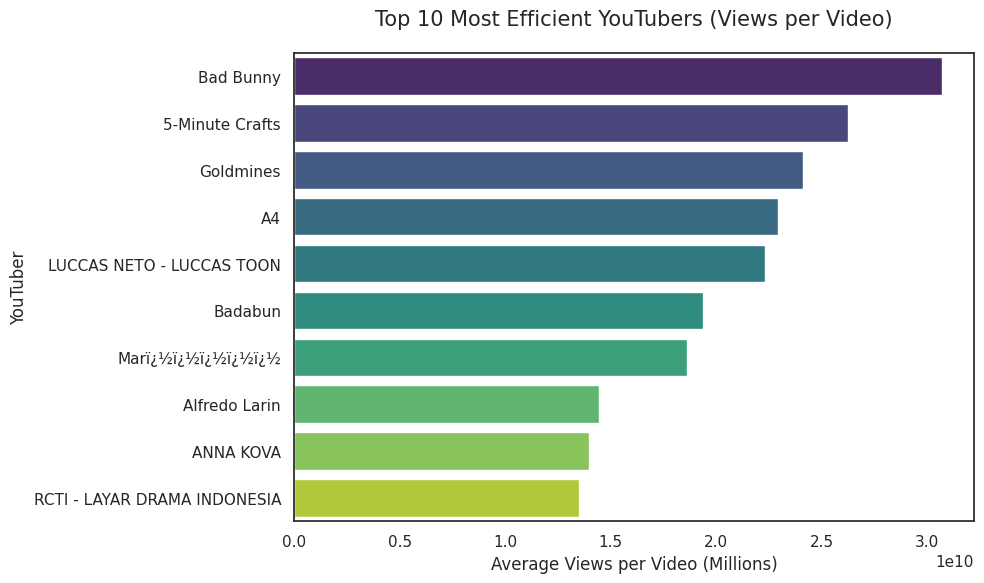

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set plot size
plt.figure(figsize=(10, 6))

# 2. Create Horizontal Bar Plot
# We use 'Views Per Video' (the metric created in the previous step)
sns.barplot(
    data=top_efficient,
    x='Views Per Video',
    y='Youtuber',
    palette='viridis'
)

# 3. Titles and Labels in English
plt.title('Top 10 Most Efficient YouTubers (Views per Video)', fontsize=15, pad=20)
plt.xlabel('Average Views per Video (Millions)', fontsize=12)
plt.ylabel('YouTuber', fontsize=12)

# 4. Save and Show
plt.tight_layout()
plt.savefig('visuals/top_efficient_youtubers.png', dpi=300, bbox_inches="tight")
plt.show()

# SUCCESS EVOLUTION OVER TIME

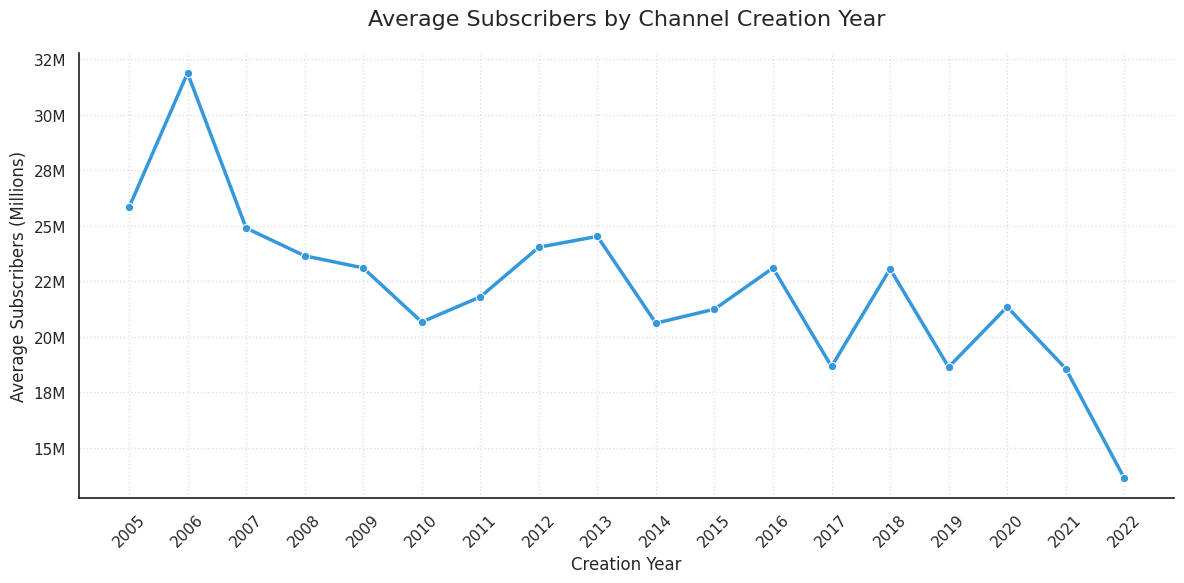

In [32]:
# Filter from 2005 onwards and group to calculate the average number of subscribers
df_time = df_clean[df_clean['Created Year'] >= 2005].groupby('Created Year')['Subscribers'].mean().reset_index()

# 1. Set plot size
plt.figure(figsize=(12, 6))

# 2. Create Line Plot
sns.lineplot(
    data=df_time,
    x='Created Year',
    y='Subscribers',
    marker='o',
    linewidth=2.5,
    color='#3498db'
)

# 3. Format Y-axis (Subscribers in Millions)
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.0f}M'))

# 4. English Titles and Labels
plt.title('Average Subscribers by Channel Creation Year', fontsize=16, pad=20)
plt.xlabel('Creation Year', fontsize=12)
plt.ylabel('Average Subscribers (Millions)', fontsize=12)

# 5. Styling and Grid
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(df_time['Created Year'], rotation=45) # Show all years on the X-axis
sns.despine()
plt.tight_layout()

# 6. Save and Show
plt.savefig('visuals/subscribers_over_time.png', dpi=300, bbox_inches="tight")
plt.show()

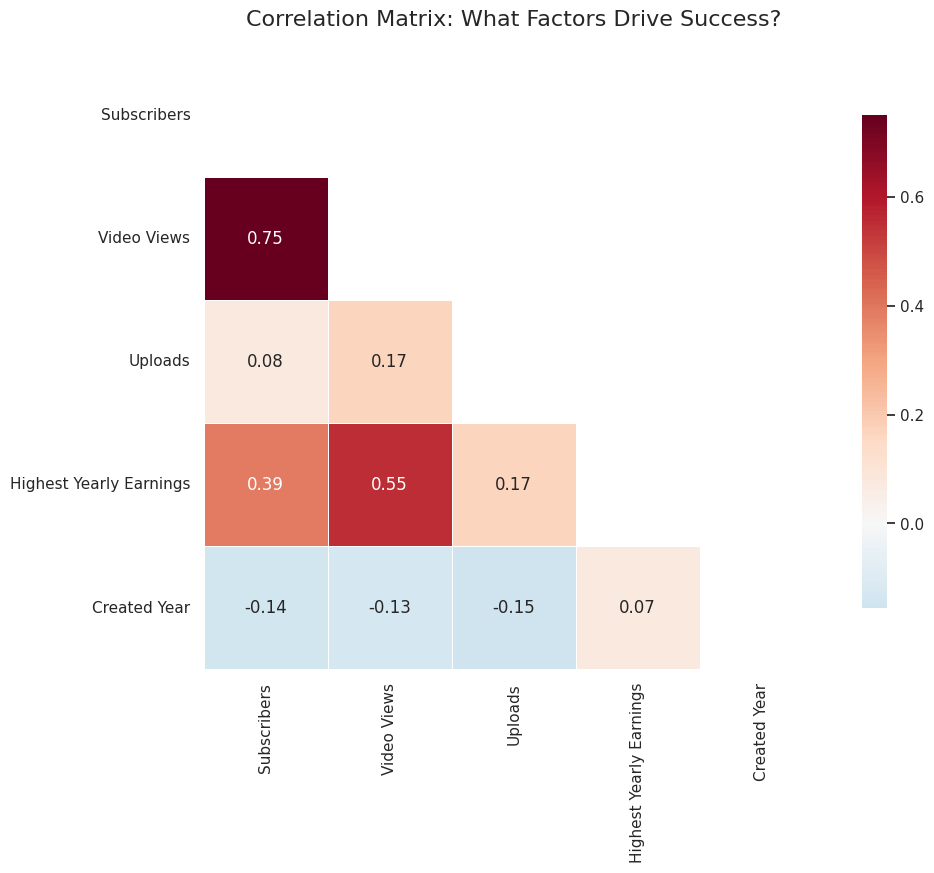

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Select only numerical columns for correlation analysis
numeric_cols = [
    'Subscribers', 'Video Views', 'Uploads',
    'Highest Yearly Earnings', 'Created Year'
]

# Include 'Views Per Video' (Efficiency metric) only if it exists in the dataframe
if 'Views Per Video' in df_clean.columns:
    numeric_cols.append('Views Per Video')

# Calculate the Pearson correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# 2. Figure configuration
plt.figure(figsize=(10, 8))

# 3. Create the Heatmap
# Upper triangle mask to avoid redundant information (very professional look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,              # Display correlation values inside the squares
    fmt=".2f",               # Format to 2 decimal places
    cmap='RdBu_r',           # Red for positive and Blue for negative correlations
    center=0,                # 0 is the neutral point
    mask=mask,               # Apply the triangle mask
    linewidths=.5,           # Add subtle lines between squares
    cbar_kws={"shrink": .8}  # Adjust color bar size
)

# 4. English Titles and Styling
plt.title('Correlation Matrix: What Factors Drive Success?', fontsize=16, pad=20)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 5. Save and Show
plt.savefig('visuals/correlation_matrix.png', dpi=300, bbox_inches="tight")
plt.show()